<center><h1>Shelar_Kartik_HW2</h1></center>
<br>
<br>

Name: Kartik Shelar
<br>
Github Username: kartikshelar
<br>
USC ID: 4217403571

## 1. Combined Cycle Power Plant Data Set

### (a) Download Data

Package imports

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
import numpy as np
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm

from itertools import combinations
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsRegressor





Get the Cycle Power Plant Data Set

In [2]:
file_path = "../data/CCPP/Folds5x2_pp.xlsx"

df = pd.read_excel(
    file_path,
    sheet_name="Sheet1",
    engine="openpyxl"
)

df.head()

,AT,V,AP,RH,PE
0,14.96,41.76,1024.07,73.17,463.26
1,25.18,62.96,1020.04,59.08,444.37
2,5.11,39.40,1012.16,92.14,488.56
3,20.86,57.32,1010.24,76.64,446.48
4,10.82,37.50,1009.23,96.62,473.90


### (b) Exploring the data

#### i. rows and columns

In [3]:
number_of_rows, number_of_columns = df.shape

print("Number of rows:", number_of_rows)
print("Number of columns:", number_of_columns)
print("Column names:", df.columns.tolist())

Number of rows: 9568
Number of columns: 5
Column names: ['AT', 'V', 'AP', 'RH', 'PE']


The dataset contains 9,568 rows and 5 columns.

Each row represents one hourly observation of the power plant. The columns consist of four predictors, ambient temperature (AT), exhaust vacuum (V), ambient pressure (AP), and relative humidity (RH) and the electrical energy output response (PE).

#### ii. pairwise scatterplots of all the varianbles

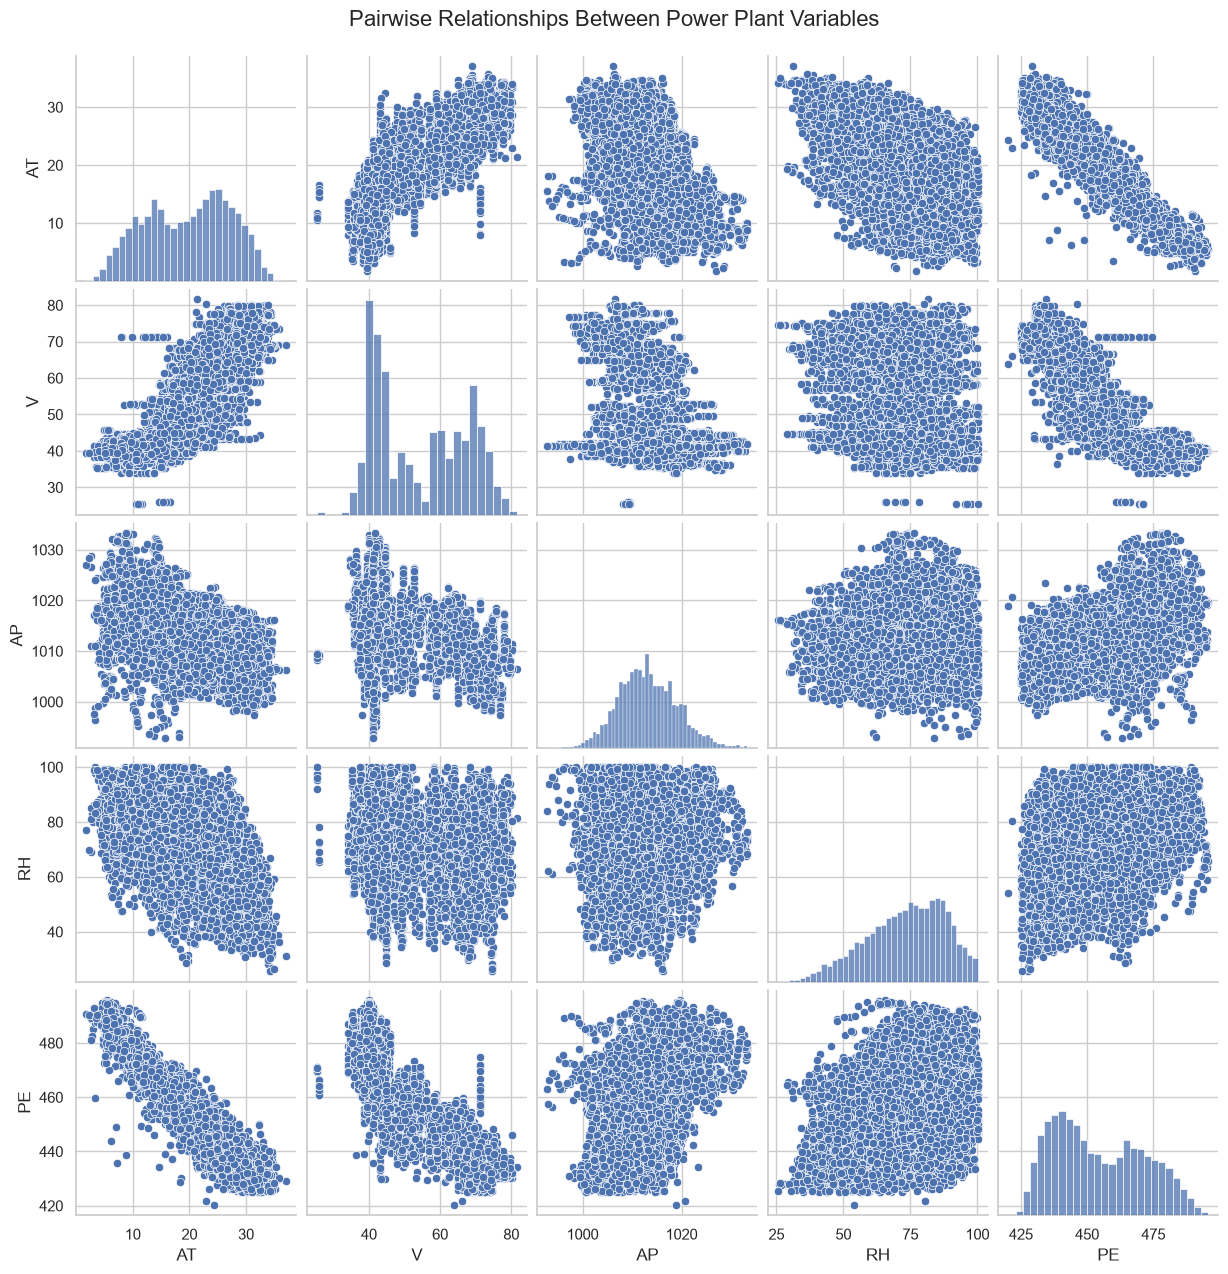

In [4]:
sns.set_theme(style="whitegrid")

pair_plot = sns.pairplot(
    df,
    diag_kind="hist",
    
)

pair_plot.figure.suptitle(
    "Pairwise Relationships Between Power Plant Variables",
    y=1.02,
    fontsize=16
)

plt.show()

In [5]:
correlation_matrix = df.corr()

correlation_matrix.round(3)

,AT,V,AP,RH,PE
AT,1.000,0.844,-0.508,-0.543,-0.948
V,0.844,1.000,-0.414,-0.312,-0.870
AP,-0.508,-0.414,1.000,0.100,0.518
RH,-0.543,-0.312,0.100,1.000,0.390
PE,-0.948,-0.870,0.518,0.390,1.000


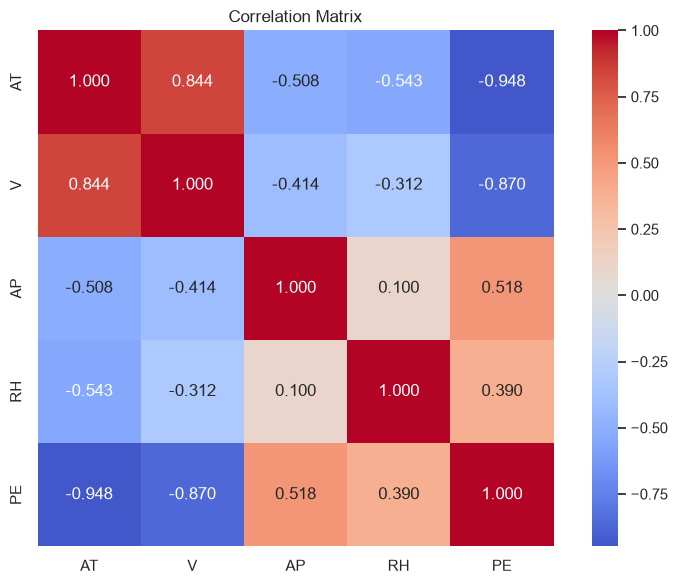

In [6]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".3f",
    cmap="coolwarm",
    center=0,
    square=True
)

plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

The pairwise scatterplots show that electrical energy output (PE) has a strong negative relationship with ambient temperature (AT) and exhaust vacuum (V). The correlations are approximately −0.948 and −0.870, respectively. This indicates that power output generally decreases as temperature or exhaust vacuum increases.

Ambient pressure (AP) has a moderate positive relationship with power output, with a correlation of approximately 0.518. Relative humidity (RH) has a weaker positive relationship with power output, with a correlation of approximately 0.390. Among the predictors, AT and V are strongly positively related, with a correlation of approximately 0.844. This suggests possible multicollinearity if both variables are included in a regression model.

#### iii. mean, the median, range, first and third quartiles, and interquartile ranges

In [7]:
summary_table = pd.DataFrame({
    "Mean": df.mean(),
    "Median": df.median(),
    "Minimum": df.min(),
    "Maximum": df.max(),
    "Range": df.max() - df.min(),
    "First Quartile (Q1)": df.quantile(0.25),
    "Third Quartile (Q3)": df.quantile(0.75),
    "IQR": df.quantile(0.75) - df.quantile(0.25)
})

summary_table.round(3)

,Mean,Median,Minimum,Maximum,Range,First Quartile (Q1),Third Quartile (Q3),IQR
AT,19.651,20.345,1.81,37.11,35.30,13.510,25.72,12.210
V,54.306,52.080,25.36,81.56,56.20,41.740,66.54,24.800
AP,1013.259,1012.940,992.89,1033.30,40.41,1009.100,1017.26,8.160
RH,73.309,74.975,25.56,100.16,74.60,63.328,84.83,21.502
PE,454.365,451.550,420.26,495.76,75.50,439.750,468.43,28.680


Ambient pressure (AP) has the smallest interquartile range relative to its numerical scale, indicating that its middle 50% of observations are concentrated within a relatively narrow interval. Relative humidity (RH) has the largest overall range, while electrical energy output (PE) ranges from 420.26 to 495.76. The mean and median of each variable are reasonably close, although V, RH, and PE show some differences that suggest mild asymmetry in their distributions.

### (c) Simple Linear Regression

In [8]:
predictors = ["AT", "V", "AP", "RH"]
models = {}
results = []

for predictor in predictors:
    X = sm.add_constant(df[[predictor]])
    y = df["PE"]

    model = sm.OLS(y, X).fit()
    models[predictor] = model

    results.append({
        "Predictor": predictor,
        "Intercept": model.params["const"],
        "Slope": model.params[predictor],
        "Slope SE": model.bse[predictor],
        "t-statistic": model.tvalues[predictor],
        "p-value": model.pvalues[predictor],
        "R-squared": model.rsquared,
        "RMSE": np.sqrt(model.mse_resid)
    })

regression_results = pd.DataFrame(results)
regression_results.round(4)

,Predictor,Intercept,Slope,Slope SE,t-statistic,p-value,R-squared,RMSE
0,AT,497.0341,-2.1713,0.0074,-291.7152,0.0,0.8989,5.4257
1,V,517.8015,-1.1681,0.0068,-172.4015,0.0,0.7565,8.4220
2,AP,-1055.2610,1.4899,0.0251,59.2962,0.0,0.2688,14.5951
3,RH,420.9618,0.4557,0.0110,41.3987,0.0,0.1519,15.7179


In [9]:
for predictor, model in models.items():
    print(f"\n{'=' * 60}")
    print(f"Simple linear regression: PE versus {predictor}")
    print("=" * 60)
    print(model.summary())


Simple linear regression: PE versus AT
                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.899
Model:                            OLS   Adj. R-squared:                  0.899
Method:                 Least Squares   F-statistic:                 8.510e+04
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        20:52:03   Log-Likelihood:                -29756.
No. Observations:                9568   AIC:                         5.952e+04
Df Residuals:                    9566   BIC:                         5.953e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       

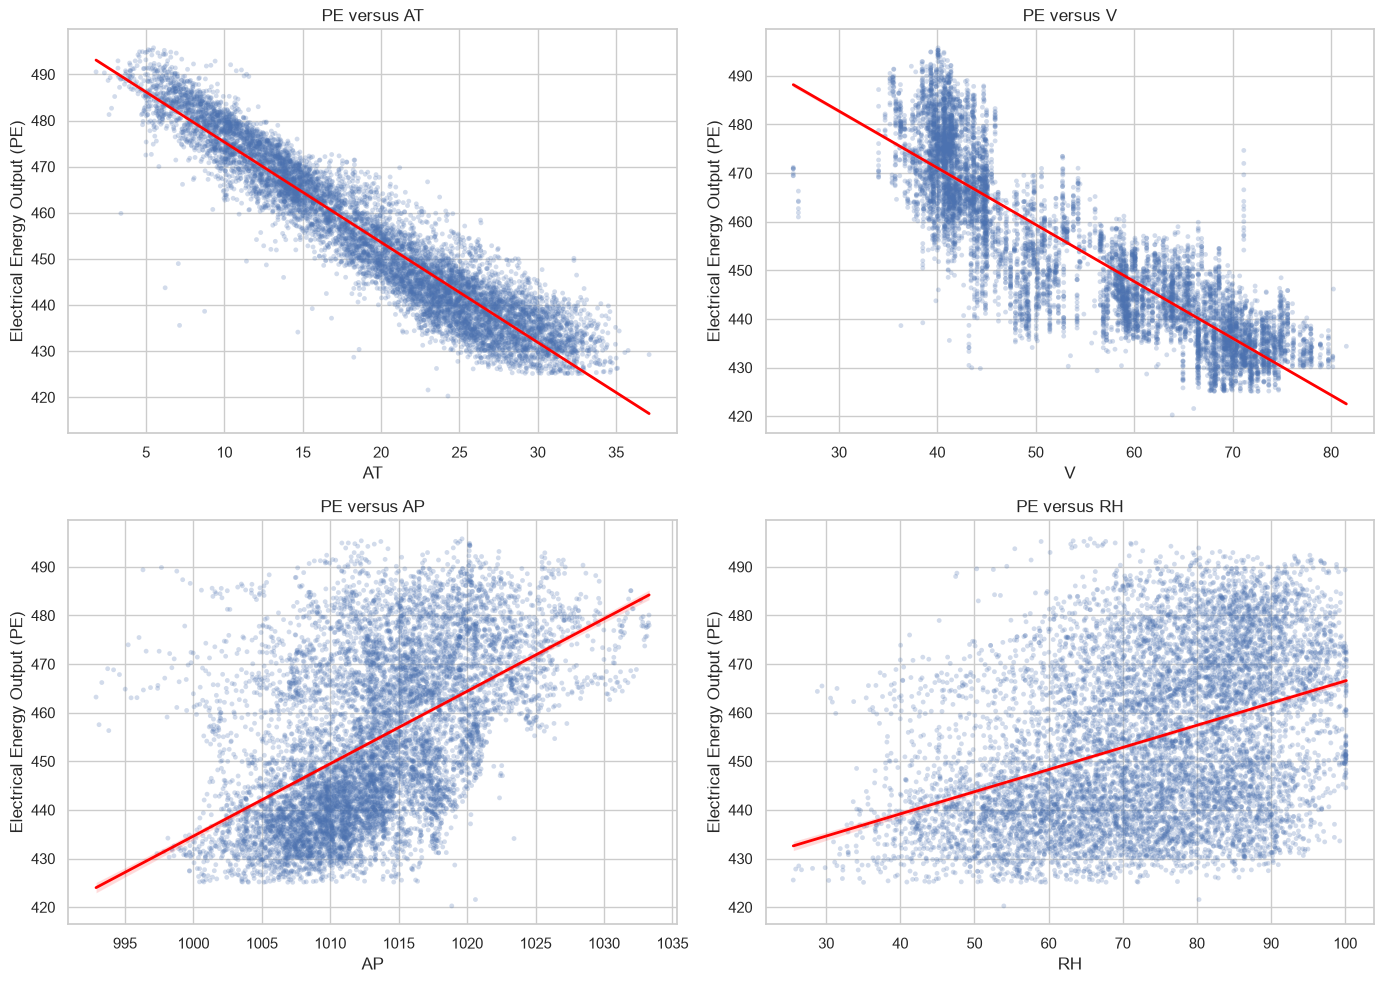

In [10]:
sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, predictor in zip(axes, predictors):
    sns.regplot(
        data=df,
        x=predictor,
        y="PE",
        ax=ax,
        scatter_kws={
            "alpha": 0.25,
            "s": 12,
            "edgecolor": "none"
        },
        line_kws={
            "color": "red",
            "linewidth": 2
        }
    )

    ax.set_title(f"PE versus {predictor}")
    ax.set_xlabel(predictor)
    ax.set_ylabel("Electrical Energy Output (PE)")

plt.tight_layout()
plt.show()

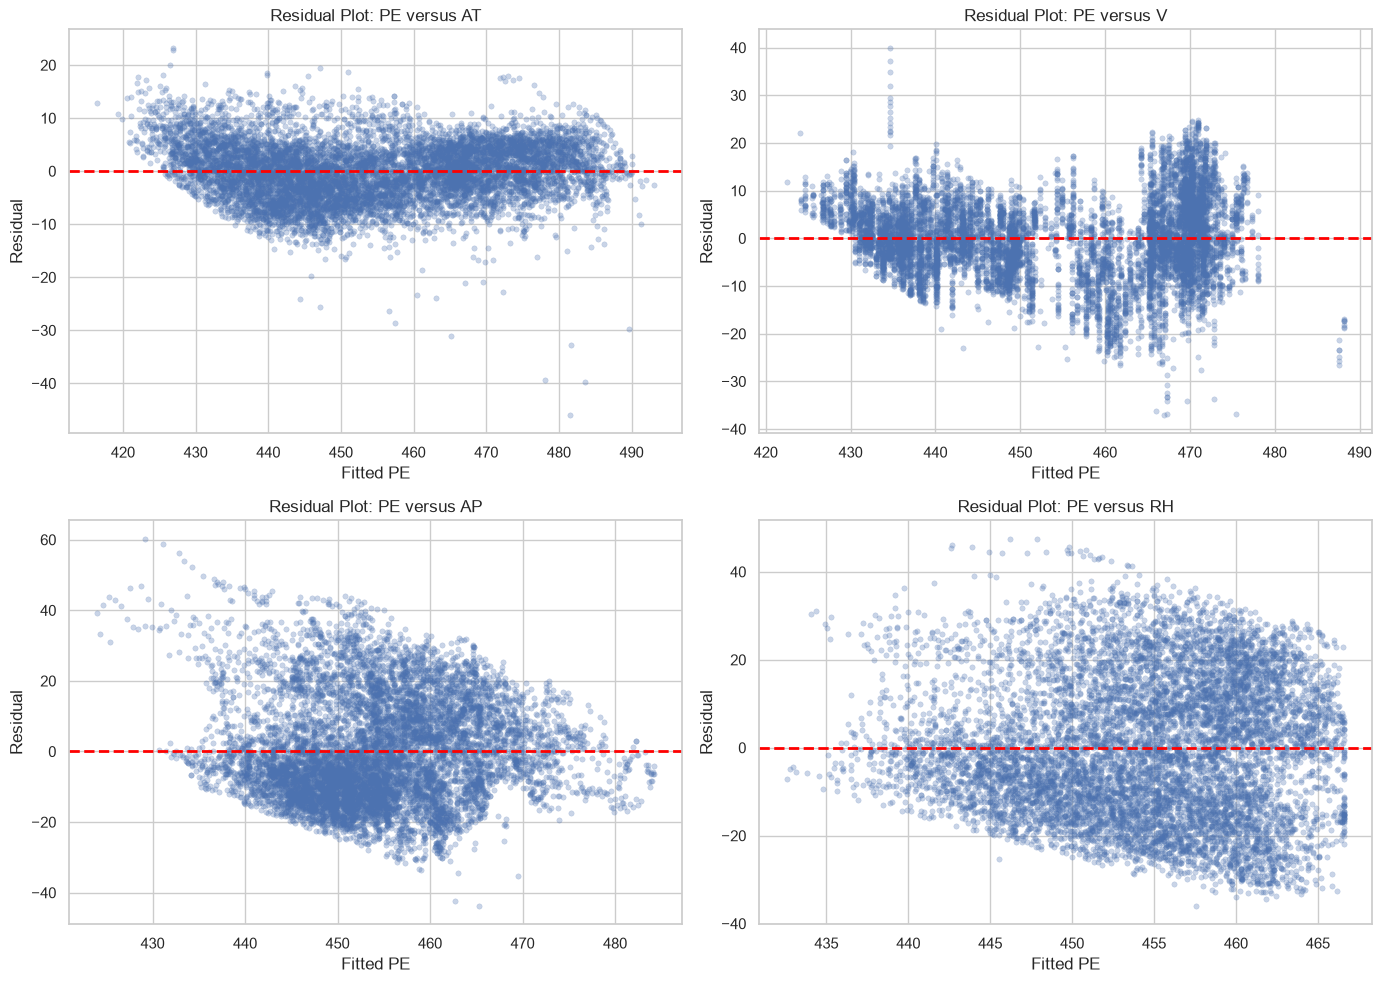

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, predictor in zip(axes, predictors):
    model = models[predictor]

    sns.scatterplot(
        x=model.fittedvalues,
        y=model.resid,
        ax=ax,
        alpha=0.3,
        s=15,
        edgecolor=None
    )

    ax.axhline(0, color="red", linestyle="--", linewidth=2)
    ax.set_title(f"Residual Plot: PE versus {predictor}")
    ax.set_xlabel("Fitted PE")
    ax.set_ylabel("Residual")

plt.tight_layout()
plt.show()

All four predictors have statistically significant associations with PE (p-values < 0.001). AT has the strongest simple linear relationship, explaining approximately 89.9% of the variation in PE, followed by V at 75.7%. AP and RH explain considerably less variation, with \(R^2\) values of approximately 0.269 and 0.152, respectively.

The estimated slopes are negative for AT and V and positive for AP and RH. The plots also show some curvature, suggesting that a linear model may not fully capture the relationships.

In [12]:
outlier_results = []
outlier_rows = {}

# Average leverage for a simple regression with n observations is (p+1)/n = 2/n
average_leverage = 2 / len(df)

for predictor, model in models.items():
    influence = model.get_influence()

    studentized_residuals = influence.resid_studentized_external
    cooks_distance = influence.cooks_distance[0]
    leverage = influence.hat_matrix_diag

    influence_data = pd.DataFrame({
        "Original_Index": df.index,
        "Studentized_Residual": studentized_residuals,
        "Cooks_Distance": cooks_distance,
        "Leverage": leverage
    })

    influence_data["Potential_Outlier"] = (
        influence_data["Studentized_Residual"].abs() > 3
    )

    influence_data["High_Leverage"] = (
        influence_data["Leverage"] > 2 * average_leverage
    )

    influence_data["Highly_Influential"] = (
        influence_data["Cooks_Distance"] > 1
    )

    outlier_rows[predictor] = influence_data

    outlier_results.append({
        "Predictor": predictor,
        "|Studentized residual| > 3": (
            influence_data["Potential_Outlier"].sum()
        ),
        "Leverage > 2x average": (
            influence_data["High_Leverage"].sum()
        ),
        "Cook's distance > 1": (
            influence_data["Highly_Influential"].sum()
        ),
        "Maximum Cook's distance": (
            influence_data["Cooks_Distance"].max()
        )
    })

outlier_summary = pd.DataFrame(outlier_results)
outlier_summary.round(5)

,Predictor,|Studentized residual| > 3,Leverage > 2x average,Cook's distance > 1,Maximum Cook's distance
0,AT,42,480,0,0.01432
1,V,33,155,0,0.00324
2,AP,30,784,0,0.00815
3,RH,2,707,0,0.00206


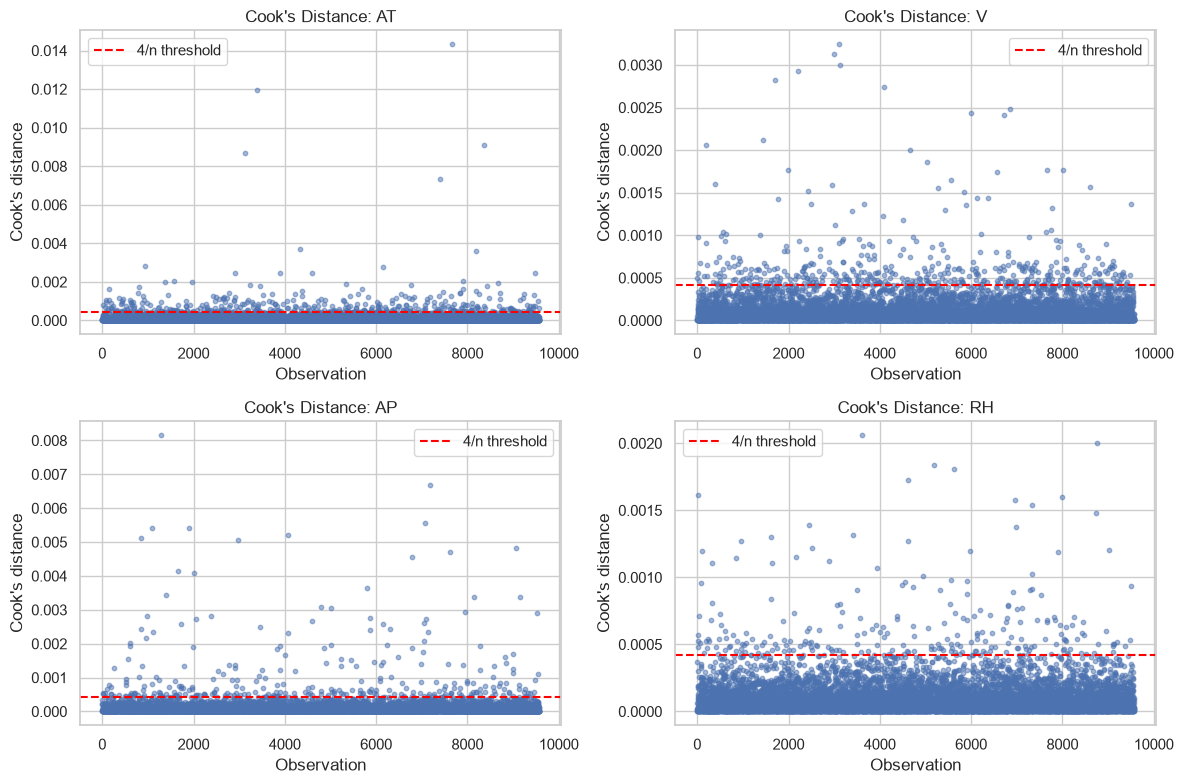

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, predictor in zip(axes.flatten(), predictors):
    cooks_distance = outlier_rows[predictor]["Cooks_Distance"]

    ax.scatter(
        np.arange(len(cooks_distance)),
        cooks_distance,
        alpha=0.5,
        s=10
    )

    ax.axhline(
        4 / len(df),
        color="red",
        linestyle="--",
        label="4/n threshold"
    )

    ax.set_title(f"Cook's Distance: {predictor}")
    ax.set_xlabel("Observation")
    ax.set_ylabel("Cook's distance")
    ax.legend()

plt.tight_layout()
plt.show()

Several observations have absolute studentized residuals greater than 3, and some exceed the \(4/n\) Cook’s-distance screening threshold. However, all Cook’s distances remain small, so no single observation appears highly influential. Therefore, I would not remove observations unless there is evidence of measurement or data-entry errors.

Therefore, I would not remove any observations unless there is evidence that they resulted from measurement or data-entry errors.

### (d) Multiple Regression

In [14]:
X = df[["AT", "V", "AP", "RH"]]

y = df["PE"]

X = sm.add_constant(X)

multiple_model = sm.OLS(y, X).fit()

print(multiple_model.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.929
Model:                            OLS   Adj. R-squared:                  0.929
Method:                 Least Squares   F-statistic:                 3.114e+04
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        20:53:10   Log-Likelihood:                -28088.
No. Observations:                9568   AIC:                         5.619e+04
Df Residuals:                    9563   BIC:                         5.622e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        454.6093      9.749     46.634      0.0

In [15]:
multiple_results = pd.DataFrame({
    "Coefficient": multiple_model.params,
    "Standard Error": multiple_model.bse,
    "t-statistic": multiple_model.tvalues,
    "p-value": multiple_model.pvalues
})

multiple_results.round(4)

,Coefficient,Standard Error,t-statistic,p-value
const,454.6093,9.7485,46.6337,0.0
AT,-1.9775,0.0153,-129.3420,0.0
V,-0.2339,0.0073,-32.1221,0.0
AP,0.0621,0.0095,6.5641,0.0
RH,-0.1581,0.0042,-37.9185,0.0


In [16]:
print("R-squared:", multiple_model.rsquared)
print("Adjusted R-squared:", multiple_model.rsquared_adj)
print("F-statistic:", multiple_model.fvalue)
print("F-test p-value:", multiple_model.f_pvalue)
print("Residual standard error:", multiple_model.mse_resid ** 0.5)

R-squared: 0.9286960898122537
Adjusted R-squared: 0.9286662648994909
F-statistic: 31138.266763667663
F-test p-value: 0.0
Residual standard error: 4.558317204269304


In [17]:
alpha = 0.05

hypothesis_results = pd.DataFrame({
    "Coefficient": multiple_model.params,
    "p-value": multiple_model.pvalues
})

hypothesis_results = hypothesis_results.drop("const")

hypothesis_results["Decision"] = hypothesis_results["p-value"].apply(
    lambda p: "Reject H0" if p < alpha else "Fail to reject H0"
)

hypothesis_results

,Coefficient,p-value,Decision
AT,-1.977513,0.000000e+00,Reject H0
V,-0.233916,4.375305e-215,Reject H0
AP,0.062083,5.507109e-11,Reject H0
RH,-0.158054,3.104584e-293,Reject H0


The multiple regression model explains approximately 92.87% of the variation in PE. At the 0.05 significance level, all four predictors are statistically significant, so ($H_0: \beta_j$=0) is rejected for AT, V, AP, and RH.

Holding the other predictors constant, AT, V, and RH have negative coefficients, while AP has a positive coefficient.

### (e) 1c Compare to 1d

In [18]:
simple_coefficients = pd.Series({
    predictor: models[predictor].params[predictor]
    for predictor in predictors
})

multiple_coefficients = multiple_model.params[predictors]

coefficient_comparison = pd.DataFrame({
    "Simple Regression": simple_coefficients,
    "Multiple Regression": multiple_coefficients
})

coefficient_comparison.index.name = "Predictor"
coefficient_comparison.round(4)

,Simple Regression,Multiple Regression
Predictor,,
AT,-2.1713,-1.9775
V,-1.1681,-0.2339
AP,1.4899,0.0621
RH,0.4557,-0.1581


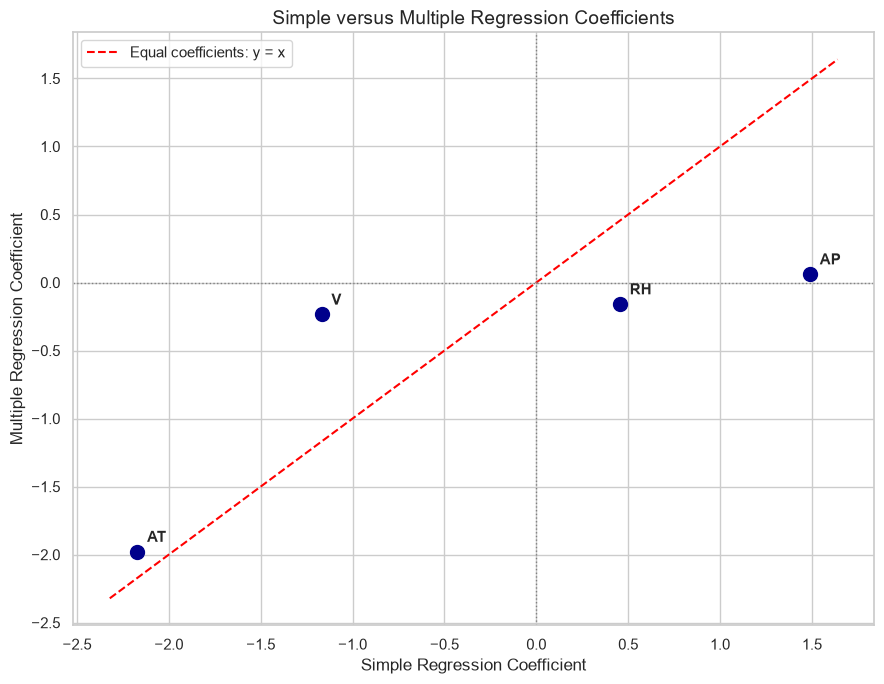

In [19]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(9, 7))

plt.scatter(
    coefficient_comparison["Simple Regression"],
    coefficient_comparison["Multiple Regression"],
    color="darkblue",
    s=100
)

# Label each point with its predictor name
for predictor, row in coefficient_comparison.iterrows():
    plt.annotate(
        predictor,
        (
            row["Simple Regression"],
            row["Multiple Regression"]
        ),
        xytext=(7, 7),
        textcoords="offset points",
        fontsize=11,
        fontweight="bold"
    )


all_coefficients = coefficient_comparison.to_numpy().flatten()
minimum = all_coefficients.min()
maximum = all_coefficients.max()
padding = 0.15

line_min = minimum - padding
line_max = maximum + padding

plt.plot(
    [line_min, line_max],
    [line_min, line_max],
    color="red",
    linestyle="--",
    linewidth=1.5,
    label="Equal coefficients: y = x"
)


plt.axhline(0, color="gray", linestyle=":", linewidth=1)
plt.axvline(0, color="gray", linestyle=":", linewidth=1)

plt.xlabel("Simple Regression Coefficient", fontsize=12)
plt.ylabel("Multiple Regression Coefficient", fontsize=12)
plt.title(
    "Simple versus Multiple Regression Coefficients",
    fontsize=14
)

plt.legend()
plt.tight_layout()
plt.show()

The coefficients change after controlling for the other predictors. The AT coefficient remains relatively similar, while the coefficients for V and AP decrease considerably in magnitude. RH changes from positive in the simple regression to negative in the multiple regression.

These differences are likely caused by correlation among the predictors, particularly the strong correlation between AT and V.

In [20]:
df[predictors].corr().round(3)

,AT,V,AP,RH
AT,1.000,0.844,-0.508,-0.543
V,0.844,1.000,-0.414,-0.312
AP,-0.508,-0.414,1.000,0.100
RH,-0.543,-0.312,0.100,1.000


The reason for these changes is that the predictors are correlated.
AT and V have a correlation of approximately 0.844, while AT and RH have a correlation of approximately −0.543. Consequently, the simple regression coefficients partly capture associations belonging to other predictors. The multiple regression coefficients estimate each predictor’s effect after statistically controlling for those relationships.

### (f) Nonlinear Association

In [21]:
predictors = ["AT", "V", "AP", "RH"]

polynomial_models = {}
nonlinear_results = []

for predictor in predictors:
    temp_df = df[["PE", predictor]].copy()

    # Centering improves numerical stability.
    # It does not change the fitted cubic curve.
    predictor_mean = temp_df[predictor].mean()
    temp_df["X_centered"] = temp_df[predictor] - predictor_mean

    # Linear model
    linear_model = smf.ols(
        "PE ~ X_centered",
        data=temp_df
    ).fit()

    # Cubic polynomial model
    cubic_model = smf.ols(
        "PE ~ X_centered + I(X_centered**2) + I(X_centered**3)",
        data=temp_df
    ).fit()

    # Compare the linear and cubic models
    comparison = anova_lm(linear_model, cubic_model)

    joint_f_statistic = comparison.loc[1, "F"]
    joint_p_value = comparison.loc[1, "Pr(>F)"]

    polynomial_models[predictor] = {
        "model": cubic_model,
        "mean": predictor_mean
    }

    nonlinear_results.append({
        "Predictor": predictor,
        "Linear R-squared": linear_model.rsquared,
        "Cubic R-squared": cubic_model.rsquared,
        "Quadratic p-value": cubic_model.pvalues[
            "I(X_centered ** 2)"
        ],
        "Cubic p-value": cubic_model.pvalues[
            "I(X_centered ** 3)"
        ],
        "Joint F-statistic": joint_f_statistic,
        "Joint p-value": joint_p_value
    })

nonlinear_results = pd.DataFrame(nonlinear_results)
nonlinear_results.round(6)

,Predictor,Linear R-squared,Cubic R-squared,Quadratic p-value,Cubic p-value,Joint F-statistic,Joint p-value
0,AT,0.898948,0.911883,0.000000,0.000000,701.967278,0.000000
1,V,0.756518,0.775022,0.000000,0.013735,393.314147,0.000000
2,AP,0.268769,0.297543,0.000000,0.000000,195.885627,0.000000
3,RH,0.151939,0.153743,0.101395,0.000014,10.188863,0.000038


In [22]:
for predictor in predictors:
    print(f"\n{'=' * 70}")
    print(f"Cubic polynomial regression for {predictor}")
    print("=" * 70)

    print(polynomial_models[predictor]["model"].summary())


Cubic polynomial regression for AT
                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.912
Model:                            OLS   Adj. R-squared:                  0.912
Method:                 Least Squares   F-statistic:                 3.299e+04
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        20:53:11   Log-Likelihood:                -29101.
No. Observations:                9568   AIC:                         5.821e+04
Df Residuals:                    9564   BIC:                         5.824e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------


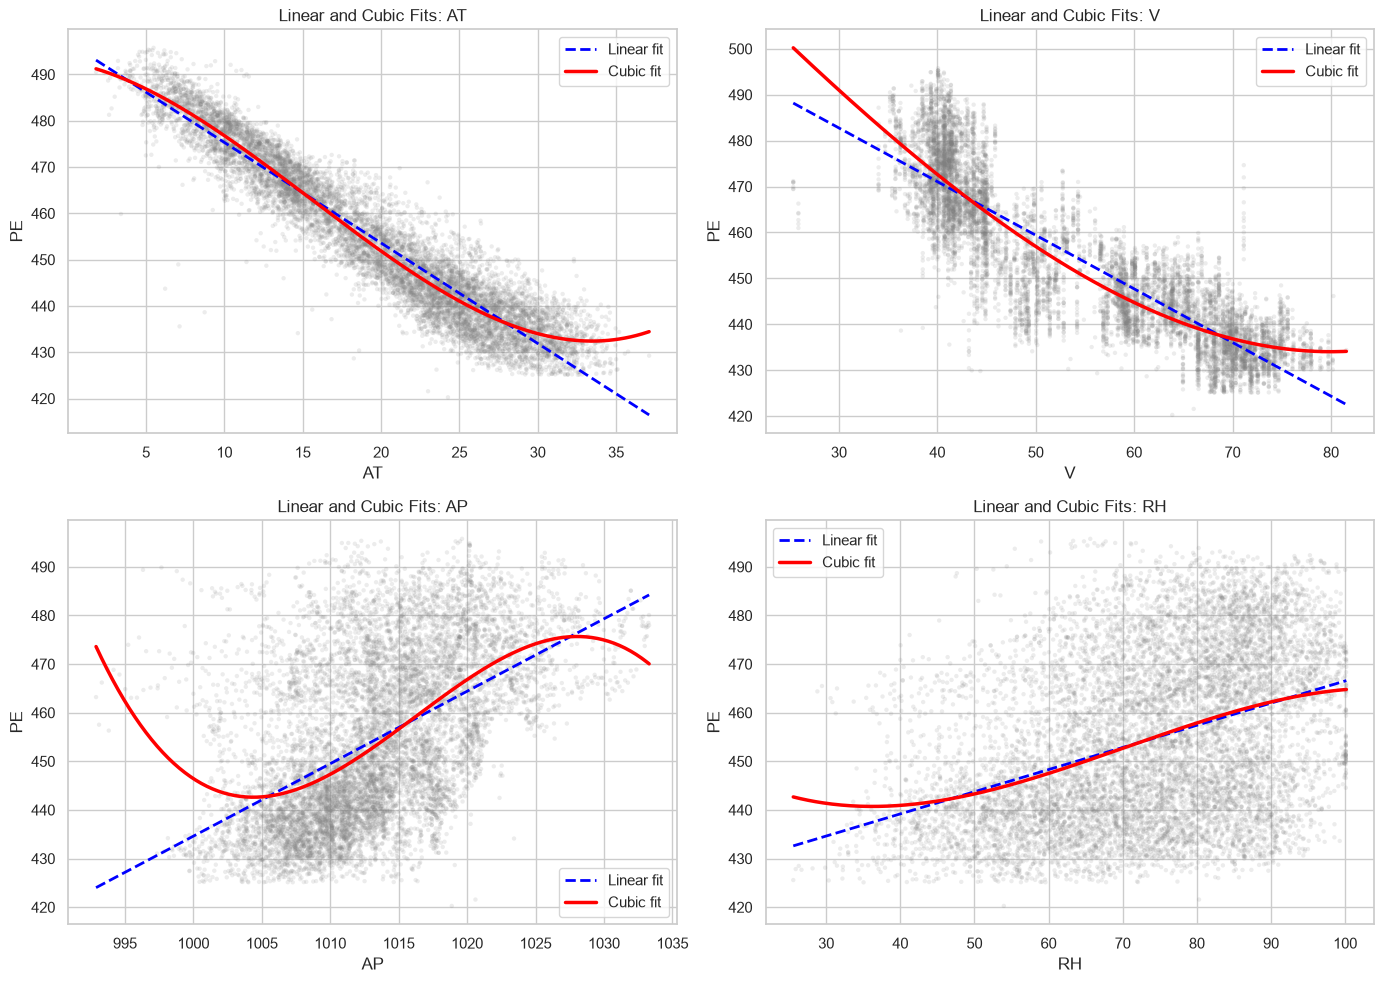

In [23]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, predictor in zip(axes, predictors):
    temp_df = df[["PE", predictor]].copy()
    predictor_mean = temp_df[predictor].mean()
    temp_df["X_centered"] = temp_df[predictor] - predictor_mean

    linear_model = smf.ols(
        "PE ~ X_centered",
        data=temp_df
    ).fit()

    cubic_model = polynomial_models[predictor]["model"]

    x_grid = np.linspace(
        df[predictor].min(),
        df[predictor].max(),
        300
    )

    prediction_data = pd.DataFrame({
        "X_centered": x_grid - predictor_mean
    })

    linear_predictions = linear_model.predict(prediction_data)
    cubic_predictions = cubic_model.predict(prediction_data)

    ax.scatter(
        df[predictor],
        df["PE"],
        alpha=0.15,
        s=10,
        color="gray",
        edgecolor="none"
    )

    ax.plot(
        x_grid,
        linear_predictions,
        color="blue",
        linewidth=2,
        linestyle="--",
        label="Linear fit"
    )

    ax.plot(
        x_grid,
        cubic_predictions,
        color="red",
        linewidth=2.5,
        label="Cubic fit"
    )

    ax.set_title(f"Linear and Cubic Fits: {predictor}")
    ax.set_xlabel(predictor)
    ax.set_ylabel("PE")
    ax.legend()

plt.tight_layout()
plt.show()

The quadratic and cubic terms are jointly significant for all four predictors, providing evidence of nonlinear relationships with PE.

The improvement is most noticeable for AT and V. Although AP and RH also have statistically significant nonlinear terms, their increases in (R^2) are small.

### (g) Interactions of Predictors

In [24]:
interaction_model = smf.ols(
    formula="PE ~ (AT + V + AP + RH) ** 2",
    data=df
).fit()

print(interaction_model.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.936
Model:                            OLS   Adj. R-squared:                  0.936
Method:                 Least Squares   F-statistic:                 1.405e+04
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        20:53:13   Log-Likelihood:                -27548.
No. Observations:                9568   AIC:                         5.512e+04
Df Residuals:                    9557   BIC:                         5.520e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    685.7825     78.640      8.721      0.0

In [25]:
interaction_terms = [
    term
    for term in interaction_model.params.index
    if ":" in term
]

interaction_results = pd.DataFrame({
    "Coefficient": interaction_model.params[interaction_terms],
    "Standard Error": interaction_model.bse[interaction_terms],
    "t-statistic": interaction_model.tvalues[interaction_terms],
    "p-value": interaction_model.pvalues[interaction_terms]
})

interaction_results["Significant at 0.05"] = (
    interaction_results["p-value"] < 0.05
)

interaction_results.round(6)

,Coefficient,Standard Error,t-statistic,p-value,Significant at 0.05
AT:V,0.020971,0.000899,23.337763,0.000000,True
AT:AP,0.001759,0.002339,0.752031,0.452051,False
AT:RH,-0.005230,0.000812,-6.444357,0.000000,True
V:AP,0.006812,0.001327,5.135000,0.000000,True
V:RH,0.000839,0.000489,1.716004,0.086194,False
AP:RH,-0.001612,0.000758,-2.125079,0.033606,True


In [26]:
additive_model = smf.ols(
    formula="PE ~ AT + V + AP + RH",
    data=df
).fit()

interaction_test = anova_lm(
    additive_model,
    interaction_model
)

interaction_test

,df_resid,ssr,df_diff,ss_diff,F,Pr(>F)
0,9563.0,198702.459591,0.0,NaN,NaN,NaN
1,9557.0,177496.627095,6.0,21205.832496,190.298584,8.064363e-230


In [27]:
model_comparison = pd.DataFrame({
    "Model": [
        "Additive model",
        "Pairwise interaction model"
    ],
    "R-squared": [
        additive_model.rsquared,
        interaction_model.rsquared
    ],
    "Adjusted R-squared": [
        additive_model.rsquared_adj,
        interaction_model.rsquared_adj
    ],
    "RMSE": [
        additive_model.mse_resid ** 0.5,
        interaction_model.mse_resid ** 0.5
    ]
})

model_comparison.round(4)

,Model,R-squared,Adjusted R-squared,RMSE
0,Additive model,0.9287,0.9287,4.5583
1,Pairwise interaction model,0.9363,0.9362,4.3096


At the 0.05 significance level, `AT:V`, `AT:RH`, `V:AP`, and `AP:RH` are statistically significant. The `AT:AP` and `V:RH` interactions are not statistically significant.

The joint F-test is also significant, showing that the interaction terms collectively improve the model compared with the additive model.

### (h) Improvement

In [28]:
predictors = ["AT", "V", "AP", "RH"]

train_df, test_df = train_test_split(
    df,
    test_size=0.30,
    random_state=42
)

print("Training observations:", len(train_df))
print("Testing observations:", len(test_df))

Training observations: 6697
Testing observations: 2871


In [29]:
# Calculate means using only the training data
training_means = train_df[predictors].mean()

def create_features(data, means):
    features = pd.DataFrame(index=data.index)

    # Centered main effects
    for predictor in predictors:
        features[predictor] = (
            data[predictor] - means[predictor]
        )

    # Quadratic terms
    for predictor in predictors:
        features[f"{predictor}_sq"] = (
            features[predictor] ** 2
        )

    # All pairwise interactions
    for first, second in combinations(predictors, 2):
        features[f"{first}_{second}"] = (
            features[first] * features[second]
        )

    return features

X_train_full = create_features(
    train_df,
    training_means
)

X_test_full = create_features(
    test_df,
    training_means
)

y_train = train_df["PE"]
y_test = test_df["PE"]

print(X_train_full.columns.tolist())

['AT', 'V', 'AP', 'RH', 'AT_sq', 'V_sq', 'AP_sq', 'RH_sq', 'AT_V', 'AT_AP', 'AT_RH', 'V_AP', 'V_RH', 'AP_RH']


In [30]:
X_train_baseline = sm.add_constant(
    X_train_full[predictors],
    has_constant="add"
)

X_test_baseline = sm.add_constant(
    X_test_full[predictors],
    has_constant="add"
)

baseline_model = sm.OLS(
    y_train,
    X_train_baseline
).fit()

baseline_train_predictions = baseline_model.predict(
    X_train_baseline
)

baseline_test_predictions = baseline_model.predict(
    X_test_baseline
)

baseline_train_mse = mean_squared_error(
    y_train,
    baseline_train_predictions
)

baseline_test_mse = mean_squared_error(
    y_test,
    baseline_test_predictions
)

print(baseline_model.summary())
print("Baseline train MSE:", baseline_train_mse)
print("Baseline test MSE:", baseline_test_mse)

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.929
Model:                            OLS   Adj. R-squared:                  0.929
Method:                 Least Squares   F-statistic:                 2.194e+04
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        20:53:13   Log-Likelihood:                -19630.
No. Observations:                6697   AIC:                         3.927e+04
Df Residuals:                    6692   BIC:                         3.930e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        454.4085      0.055   8193.942      0.0

In [31]:
all_features = X_train_full.columns.tolist()

parents = {}

# Quadratic terms require their corresponding main effects
for predictor in predictors:
    parents[f"{predictor}_sq"] = {predictor}

# Interaction terms require both main effects
for first, second in combinations(predictors, 2):
    parents[f"{first}_{second}"] = {first, second}

In [32]:
def fit_model(feature_names):
    X = sm.add_constant(
        X_train_full[feature_names],
        has_constant="add"
    )

    return sm.OLS(y_train, X).fit()


def main_effect_is_required(main_effect, selected_features):
    for higher_order_term, required_parents in parents.items():
        if (
            higher_order_term in selected_features
            and main_effect in required_parents
        ):
            return True

    return False


selected_features = all_features.copy()
removal_history = []

while True:
    current_model = fit_model(selected_features)

    removable_candidates = []

    for feature in selected_features:
        p_value = current_model.pvalues[feature]

        # A main effect cannot be removed when a remaining
        # square or interaction depends on it.
        if feature in predictors:
            if main_effect_is_required(
                feature,
                selected_features
            ):
                continue

        if p_value > 0.05:
            removable_candidates.append(
                (feature, p_value)
            )

    # Stop when every removable variable is significant
    if not removable_candidates:
        break

    # Remove the eligible variable with the largest p-value
    feature_to_remove, largest_p_value = max(
        removable_candidates,
        key=lambda item: item[1]
    )

    selected_features.remove(feature_to_remove)

    removal_history.append({
        "Removed variable": feature_to_remove,
        "p-value when removed": largest_p_value
    })

selected_model = fit_model(selected_features)

In [33]:
removal_history_df = pd.DataFrame(removal_history)
removal_history_df

,Removed variable,p-value when removed
0,V_RH,0.867382
1,V_sq,0.607733
2,V_AP,0.357826


In [34]:
print("Final selected features:")

for feature in selected_features:
    print(feature)

Final selected features:
AT
V
AP
RH
AT_sq
AP_sq
RH_sq
AT_V
AT_AP
AT_RH
AP_RH


In [35]:
print(selected_model.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.938
Model:                            OLS   Adj. R-squared:                  0.938
Method:                 Least Squares   F-statistic:                     9258.
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        20:53:13   Log-Likelihood:                -19161.
No. Observations:                6697   AIC:                         3.835e+04
Df Residuals:                    6685   BIC:                         3.843e+04
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        453.2275      0.099   4582.006      0.0

In [36]:
selected_results = pd.DataFrame({
    "Coefficient": selected_model.params,
    "Standard Error": selected_model.bse,
    "t-statistic": selected_model.tvalues,
    "p-value": selected_model.pvalues
})

selected_results.round(6)

,Coefficient,Standard Error,t-statistic,p-value
const,453.227507,0.098915,4582.006192,0.000000
AT,-1.817267,0.019482,-93.280225,0.000000
V,-0.298531,0.008887,-33.593352,0.000000
AP,0.116926,0.011569,10.106816,0.000000
RH,-0.125096,0.005111,-24.473779,0.000000
AT_sq,0.019534,0.002408,8.112485,0.000000
AP_sq,-0.007644,0.001335,-5.725951,0.000000
RH_sq,-0.001940,0.000275,-7.046218,0.000000
AT_V,0.008246,0.001456,5.663172,0.000000
AT_AP,0.006975,0.002197,3.174497,0.001508


In [37]:
X_train_selected = sm.add_constant(
    X_train_full[selected_features],
    has_constant="add"
)

X_test_selected = sm.add_constant(
    X_test_full[selected_features],
    has_constant="add"
)

selected_train_predictions = selected_model.predict(
    X_train_selected
)

selected_test_predictions = selected_model.predict(
    X_test_selected
)

selected_train_mse = mean_squared_error(
    y_train,
    selected_train_predictions
)

selected_test_mse = mean_squared_error(
    y_test,
    selected_test_predictions
)

mse_results = pd.DataFrame({
    "Model": [
        "Baseline additive model",
        "Selected nonlinear/interaction model"
    ],
    "Train MSE": [
        baseline_train_mse,
        selected_train_mse
    ],
    "Test MSE": [
        baseline_test_mse,
        selected_test_mse
    ]
})

mse_results.round(4)

,Model,Train MSE,Test MSE
0,Baseline additive model,20.5808,21.2399
1,Selected nonlinear/interaction model,17.8908,18.6600


In [38]:
test_mse_reduction = (
    (baseline_test_mse - selected_test_mse)
    / baseline_test_mse
) * 100

print(
    f"Test MSE reduction: {test_mse_reduction:.2f}%"
)

Test MSE reduction: 12.15%


The baseline model produced training and test MSEs of approximately 20.58 and 21.24. Backward elimination removed `V:RH`, (V^2), and `V:AP` while retaining the required main effects.

The selected model produced training and test MSEs of approximately 17.89 and 18.66. Its test MSE is about 12.15% lower than the baseline model's, indicating that the selected nonlinear and interaction terms improve prediction.

### (i) KNN

In [39]:
predictors = ["AT", "V", "AP", "RH"]

X = df[predictors]
y = df["PE"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42
)

print("Training observations:", len(X_train))
print("Testing observations:", len(X_test))

Training observations: 6697
Testing observations: 2871


In [40]:
scaler = MinMaxScaler()

X_train_normalized = scaler.fit_transform(X_train)
X_test_normalized = scaler.transform(X_test)

In [41]:
k_values = range(1, 101)

raw_train_mse = []
raw_test_mse = []

normalized_train_mse = []
normalized_test_mse = []

for k in k_values:
    # KNN using raw features
    raw_model = KNeighborsRegressor(
        n_neighbors=k
    )

    raw_model.fit(X_train, y_train)

    raw_train_predictions = raw_model.predict(X_train)
    raw_test_predictions = raw_model.predict(X_test)

    raw_train_mse.append(
        mean_squared_error(
            y_train,
            raw_train_predictions
        )
    )

    raw_test_mse.append(
        mean_squared_error(
            y_test,
            raw_test_predictions
        )
    )

    # KNN using normalized features
    normalized_model = KNeighborsRegressor(
        n_neighbors=k
    )

    normalized_model.fit(
        X_train_normalized,
        y_train
    )

    normalized_train_predictions = (
        normalized_model.predict(X_train_normalized)
    )

    normalized_test_predictions = (
        normalized_model.predict(X_test_normalized)
    )

    normalized_train_mse.append(
        mean_squared_error(
            y_train,
            normalized_train_predictions
        )
    )

    normalized_test_mse.append(
        mean_squared_error(
            y_test,
            normalized_test_predictions
        )
    )

In [42]:
best_raw_index = np.argmin(raw_test_mse)
best_normalized_index = np.argmin(normalized_test_mse)

best_raw_k = list(k_values)[best_raw_index]
best_normalized_k = list(k_values)[best_normalized_index]

print("Raw features")
print("Best k:", best_raw_k)
print(
    "Training MSE:",
    raw_train_mse[best_raw_index]
)
print(
    "Testing MSE:",
    raw_test_mse[best_raw_index]
)

print("\nNormalized features")
print("Best k:", best_normalized_k)
print(
    "Training MSE:",
    normalized_train_mse[best_normalized_index]
)
print(
    "Testing MSE:",
    normalized_test_mse[best_normalized_index]
)

Raw features
Best k: 5
Training MSE: 10.600768887561596
Testing MSE: 15.726819842563568

Normalized features
Best k: 4
Training MSE: 8.454347681797822
Testing MSE: 14.291333431295715


In [43]:
knn_results = pd.DataFrame({
    "k": list(k_values),
    "1/k": [1 / k for k in k_values],
    "Raw Train MSE": raw_train_mse,
    "Raw Test MSE": raw_test_mse,
    "Normalized Train MSE": normalized_train_mse,
    "Normalized Test MSE": normalized_test_mse
})

knn_results.head()

,k,1/k,Raw Train MSE,Raw Test MSE,Normalized Train MSE,Normalized Test MSE
0,1,1.000000,0.000000,20.332543,0.000000,18.298757
1,2,0.500000,5.500468,17.344087,5.204069,15.700308
2,3,0.333333,8.126551,16.338840,7.168283,14.605432
3,4,0.250000,9.444740,15.810755,8.454348,14.291333
4,5,0.200000,10.600769,15.726820,9.602599,14.446174


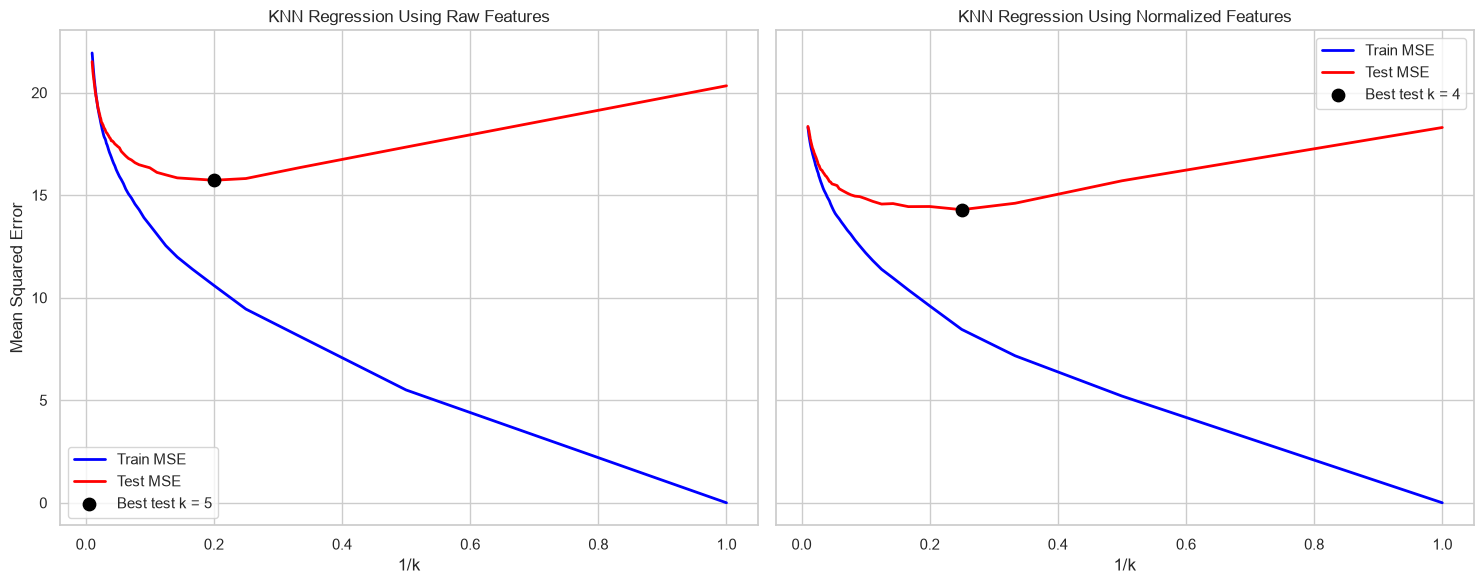

In [44]:
sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(
    1,
    2,
    figsize=(15, 6),
    sharey=True
)

# Sort so that 1/k increases from left to right
plot_results = knn_results.sort_values("1/k")

# Raw features
axes[0].plot(
    plot_results["1/k"],
    plot_results["Raw Train MSE"],
    label="Train MSE",
    color="blue",
    linewidth=2
)

axes[0].plot(
    plot_results["1/k"],
    plot_results["Raw Test MSE"],
    label="Test MSE",
    color="red",
    linewidth=2
)

axes[0].scatter(
    1 / best_raw_k,
    raw_test_mse[best_raw_index],
    color="black",
    s=80,
    zorder=5,
    label=f"Best test k = {best_raw_k}"
)

axes[0].set_title("KNN Regression Using Raw Features")
axes[0].set_xlabel("1/k")
axes[0].set_ylabel("Mean Squared Error")
axes[0].legend()

# Normalized features
axes[1].plot(
    plot_results["1/k"],
    plot_results["Normalized Train MSE"],
    label="Train MSE",
    color="blue",
    linewidth=2
)

axes[1].plot(
    plot_results["1/k"],
    plot_results["Normalized Test MSE"],
    label="Test MSE",
    color="red",
    linewidth=2
)

axes[1].scatter(
    1 / best_normalized_k,
    normalized_test_mse[best_normalized_index],
    color="black",
    s=80,
    zorder=5,
    label=f"Best test k = {best_normalized_k}"
)

axes[1].set_title(
    "KNN Regression Using Normalized Features"
)
axes[1].set_xlabel("1/k")
axes[1].legend()

plt.tight_layout()
plt.show()

For the raw predictors, the lowest test MSE was approximately 15.73 at (k=5). For the normalized predictors, the lowest test MSE was approximately 14.29 at (k=4).

The normalized model performed better because KNN is distance-based, so predictors with larger numerical scales can dominate when the data are not normalized. The results also show overfitting at very small (k) and smoother predictions as (k) increases.

### (j ) Compare KNN and Linear

In [45]:
model_comparison = pd.DataFrame({
    "Model": [
        "Selected nonlinear/interaction regression",
        "KNN using raw features (k=5)",
        "KNN using normalized features (k=4)"
    ],
    "Train MSE": [
        selected_train_mse,
        raw_train_mse[best_raw_index],
        normalized_train_mse[best_normalized_index]
    ],
    "Test MSE": [
        selected_test_mse,
        raw_test_mse[best_raw_index],
        normalized_test_mse[best_normalized_index]
    ]
})

model_comparison["Train-Test Gap"] = (
    model_comparison["Test MSE"]
    - model_comparison["Train MSE"]
)

model_comparison.round(4)

,Model,Train MSE,Test MSE,Train-Test Gap
0,Selected nonlinear/interaction regression,17.8908,18.6600,0.7692
1,KNN using raw features (k=5),10.6008,15.7268,5.1261
2,KNN using normalized features (k=4),8.4543,14.2913,5.8370


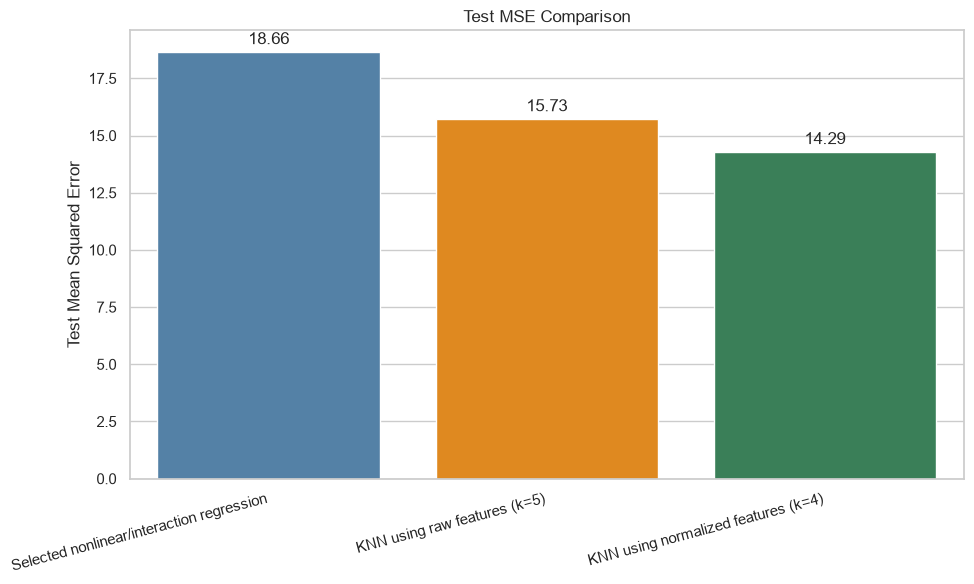

In [46]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=model_comparison,
    x="Model",
    y="Test MSE",
    hue="Model",
    palette=["steelblue", "darkorange", "seagreen"],
    legend=False
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f",
        padding=3
    )

plt.title("Test MSE Comparison")
plt.xlabel("")
plt.ylabel("Test Mean Squared Error")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()

The selected regression model had a test MSE of approximately 18.66. Raw KNN achieved a lower test MSE of approximately 15.73, while normalized KNN achieved the lowest test MSE of approximately 14.29.

Therefore, normalized KNN with (k=4) provides the best predictive performance. The regression model remains easier to interpret because it provides coefficients describing the predictors’ estimated effects.

## 2. ISLR: 2.4.1

### (a) The sample size n is extremely large, and the number of predictors p is small.

A flexible method would generally perform better.

With many observations and only a few predictors, the model has enough data to estimate a complex relationship reliably. The risk of overfitting is relatively low, so a flexible method can capture patterns that an inflexible method might miss.

### (b) The number of predictors p is extremely large, and the number of observations n is small.

A flexible method would generally perform worse.

When $n$ is small and $p$ is large, flexible models easily fit the noise in the data rather than the true underlying relationship, leading to severe overfitting and high variance. An inflexible method imposes structural constraints that restrict model complexity, keeping variance manageable.

### (c) The relationship between the predictors and response is highly non-linear.

A flexible method would generally perform better.

Inflexible methods (such as linear regression) make rigid structural assumptions about the function $f(X)$. If the true relationship is non-linear, an inflexible method will suffer from high bias. A flexible method has the degrees of freedom required to fit complex non-linear patterns, yielding lower bias and better overall fit.

### (d) The variance of the error terms, i.e. $σ^2$ = Var(ε), is extremely high.

A flexible method would generally perform worse.

High error variance means the data contain substantial random noise. A flexible method may mistakenly fit this noise as though it were a real pattern, causing high variance and overfitting. An inflexible method is less likely to follow the noise and will generally perform better on unseen data.

## 3. ISLR: 2.4.7

### (a) Compute the Euclidean distance between each observation and the test point, X1 = X2 = X3 = 0.

The Euclidean distance between each observation $X=(X_1,X_2,X_3)$ and the test point $X_0 = (0,0,0)$ is calculated using $d(X,X_0)=\sqrt{(X_1-0)^2+(X_2-0)^2+(X_3-0)^2}$:

Observation 1: \(0,3,0\), Red:\
 $\sqrt{(0-0)^2 + (3-0)^2 + (0-0)^2} = \sqrt{9} = 3$  

Observation 2: \(2,0,0\), Red:\
 $\sqrt{(2-0)^2 + (0-0)^2 + (0-0)^2} = \sqrt{4} = 2$  

Observation 3: \(0,1,3\), Red:\
 $\sqrt{(0-0)^2 + (1-0)^2 + (3-0)^2} = \sqrt{1 + 9} = \sqrt{10} \approx 3.16$  

Observation 4: \(0,1,2\), Green:\
 $\sqrt{(0-0)^2 + (1-0)^2 + (2-0)^2} = \sqrt{1 + 4} = \sqrt{5} \approx 2.24$  

Observation 5: \(-1,0,1\), Green:\
 $\sqrt{(-1-0)^2 + (0-0)^2 + (1-0)^2} = \sqrt{1 + 1} = \sqrt{2} \approx 1.41$  

Observation 6: \(1,1,1\), Red:\
 $\sqrt{(1-0)^2 + (1-0)^2 + (1-0)^2} = \sqrt{1 + 1 + 1} = \sqrt{3} \approx 1.73$

### (b) What is our prediction with K = 1? Why?

For K=1, we use only the single closest observation.

The single nearest neighbor (smallest distance) to the test point is Observation 5 with $d = \sqrt{2} \approx 1.41$.

Since its class label is Green, the 1-nearest neighbor classification prediction is Green.

Prediction: Green

### (c) What is our prediction with K = 3? Why?

For K=3, we use only the 3 closest observations.

The three nearest neighbors to the test point are:  
Observation 5 ($d \approx 1.41$, Y = Green)  
Observation 6 ($d \approx 1.73$, Y = Red)  
Observation 2 ($d = 2.00$, Y = Red)

Among these 3 neighbors, the probability of   
Y = Red is $2/3 \approx 66.7\%$ and   
Y = Green is $1/3 \approx 33.3\%$.

By majority vote, the prediction is Red.

Prediction: Red


### (d) If the Bayes decision boundary in this problem is highly non-linear, then would we expect the best value for K to be large or small? Why?

We would generally expect the best value of K to be small.

A small K produces a flexible decision boundary because the prediction depends only on observations very close to the test point. This allows KNN to follow complex, highly nonlinear patterns.

A large K averages over many observations and produces a smoother, less flexible decision boundary. It may fail to capture a highly nonlinear relationship.

Therefore, 
A small value of K is generally preferred.

The exact best value should still be selected using validation or cross-validation because making K too small can lead to overfitting.

## References and Citations

The following resources were consulted while completing this assignment:

1. **James, G., Witten, D., Hastie, T., Tibshirani, R., and Taylor, J.**  
   *An Introduction to Statistical Learning: With Applications in Python.*  
   Used as a reference for simple and multiple linear regression, polynomial regression, interaction effects, model assessment, the bias–variance trade-off, and K-nearest neighbors.  
   https://www.statlearning.com/

2. **UCI Machine Learning Repository — Combined Cycle Power Plant Dataset.**  
   Used for the dataset description, predictor definitions, response-variable information, and original data source.  
   https://archive.ics.uci.edu/dataset/294/combined+cycle+power+plant

3. **Statsmodels — Ordinary Least Squares Regression.**  
   Used as a reference for fitting and interpreting OLS regression models, coefficient estimates, standard errors, t-statistics, p-values, \(R^2\), and adjusted \(R^2\).  
   https://www.statsmodels.org/stable/regression.html

4. **Statsmodels — Interactions and ANOVA.**  
   Used as a reference for fitting interaction models and comparing nested regression models with F-tests.  
   https://www.statsmodels.org/stable/examples/notebooks/generated/interactions_anova.html


5. **Scikit-learn Documentation.**  
   Used as a reference for splitting the data, normalizing predictors, implementing K-nearest-neighbor regression, and calculating mean squared error.  
   https://scikit-learn.org/stable/